# 导包

In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
import torch
import transformers
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModel
from Bio import SeqIO
from Bio.SeqIO import FastaIO
import scipy.stats as stats
import torch.nn.functional as F
from tqdm import tqdm
import gc

# 模型加载

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
orthrus_4 = AutoModel.from_pretrained(
    "antichronology/orthrus-4-track",
    trust_remote_code=True
).to(device)
# orthrus_4

# 准备数据

In [3]:
os.getcwd()

'/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse'

In [5]:
# 读取数据
syntenic_df = pd.read_excel('共线表_41588_2023_1620_MOESM2_ESM.xlsx', sheet_name='Supplementary Table 2a')  # 共线表
homologous_df = pd.read_excel('同源表_41588_2023_1620_MOESM4_ESM.xlsx', sheet_name='human vs mouse')  # 同源表

# 构建同源&共线不同源

In [9]:
# ==================== 通用函数部分 ====================
def extract_ids(description, species):
    """通用ID提取函数"""
    parts = [part.strip() for part in description.split('|')]
    if species == "human":
        transcript_id = parts[0].split('.')[0]  # 去除版本号
        gene_id = parts[1].split('.')[0]        # 去除版本号
    else:  # specie2 或其他物种
        # transcript_id = parts[0]
        # gene_id = parts[1]
        transcript_id = parts[0].split('.')[0]  # 去除版本号
        gene_id = parts[1].split('.')[0]        # 去除版本号
    return transcript_id, gene_id

def get_longest_transcript(fasta_file, species):
    """获取每个基因的最长转录本"""
    gene_to_longest = {}
    for record in SeqIO.parse(fasta_file,"fasta"):
        # 序列大写化
        record.seq = record.seq.upper()
        _, gene_id = extract_ids(record.description, species)
        if gene_id not in gene_to_longest or len(record.seq) > len(gene_to_longest[gene_id].seq):
            gene_to_longest[gene_id] = record
    return gene_to_longest

def get_transcript_dict(fasta_file, species):
    """构建转录本ID到记录的映射"""
    transcript_dict = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        # 序列大写化
        record.seq = record.seq.upper()
        transcript_id, _ = extract_ids(record.description, species)
        transcript_dict[transcript_id] = record
    return transcript_dict

def get_transcript_to_gene(fasta_file, species):
    """构建转录本到基因的映射"""
    transcript_to_gene = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        transcript_id, gene_id = extract_ids(record.description, species)
        transcript_to_gene[transcript_id] = gene_id
    return transcript_to_gene

def write_fasta_biopython(records, filename):
    """写入FASTA文件，设置wrap=None确保序列不换行"""
    with open(filename, "w") as output_handle:
        writer = FastaIO.FastaWriter(output_handle, wrap=None)
        writer.write_file(records)

In [10]:
# ==================== 流程执行部分 ====================
# 处理共线数据集
human_longest = get_longest_transcript('gencode.v25.lncRNA_transcripts.fa', 'human')
specie2_longest = get_longest_transcript('gencode.vM10.lncRNA_transcripts.fa', 'specie2')

human_syntenic_records = [human_longest[gene] for gene in syntenic_df['human gene'] if gene in human_longest]
specie2_syntenic_records = [specie2_longest[gene] for gene in syntenic_df['mouse gene'] if gene in specie2_longest]

# 处理同源数据集
human_transcripts = get_transcript_dict('gencode.v25.lncRNA_transcripts.fa', 'human')
specie2_transcripts = get_transcript_dict('gencode.vM10.lncRNA_transcripts.fa', 'specie2')

human_homo_records = [human_transcripts[t] for t in homologous_df['human transcript'] if t in human_transcripts]
specie2_homo_records = [specie2_transcripts[t] for t in homologous_df['mouse transcript'] if t in specie2_transcripts]

# 处理共线不同源数据集
human_transcript_to_gene = get_transcript_to_gene('gencode.v25.lncRNA_transcripts.fa', 'human')
specie2_transcript_to_gene = get_transcript_to_gene('gencode.vM10.lncRNA_transcripts.fa', 'specie2')

# 收集同源表中的基因对
homologous_gene_pairs = []
for _, row in homologous_df.iterrows():
    human_transcript = row['human transcript']
    specie2_transcript = row['mouse transcript']
    
    if human_transcript in human_transcript_to_gene and specie2_transcript in specie2_transcript_to_gene:
        human_gene = human_transcript_to_gene[human_transcript]
        specie2_gene = specie2_transcript_to_gene[specie2_transcript]
        homologous_gene_pairs.append((human_gene, specie2_gene))

# 收集共线表中的基因对
syntenic_gene_pairs = []
for _, row in syntenic_df.iterrows():
    human_gene = row['human gene']
    specie2_gene = row['mouse gene']
    syntenic_gene_pairs.append((human_gene, specie2_gene))

# 找出共线但不同源的基因对
homologous_gene_pairs_set = set(homologous_gene_pairs)
syntenic_non_homologous_gene_pairs = [pair for pair in syntenic_gene_pairs if pair not in homologous_gene_pairs_set]

# 提取这些基因对中的基因
syntenic_non_homologous_human_genes = [pair[0] for pair in syntenic_non_homologous_gene_pairs]
syntenic_non_homologous_specie2_genes = [pair[1] for pair in syntenic_non_homologous_gene_pairs]

# 提取最长转录本
human_syntenic_non_homologous_records = [human_longest[gene] for gene in syntenic_non_homologous_human_genes if gene in human_longest]
specie2_syntenic_non_homologous_records = [specie2_longest[gene] for gene in syntenic_non_homologous_specie2_genes if gene in specie2_longest]

# 输出所有文件
write_fasta_biopython(human_syntenic_records, "HM_human_syntenic.fa")
write_fasta_biopython(specie2_syntenic_records, "Mouse_syntenic.fa")
write_fasta_biopython(human_homo_records, "HM_human_homo.fa")
write_fasta_biopython(specie2_homo_records, "Mouse_homo.fa")
write_fasta_biopython(human_syntenic_non_homologous_records, "HM_human_syntenic_non_homologous.fa")
write_fasta_biopython(specie2_syntenic_non_homologous_records, "Mouse_syntenic_non_homologous.fa")

# 输出统计信息
print(f"人类共线基因数量: {len(human_syntenic_records)}")
print(f"小鼠共线基因数量: {len(specie2_syntenic_records)}")
print(f"人类同源基因数量: {len(human_homo_records)}")
print(f"小鼠同源基因数量: {len(specie2_homo_records)}")
print(f"同源基因对数量: {len(homologous_gene_pairs)}")
print(f"共线基因对数量: {len(syntenic_gene_pairs)}")
print(f"共线不同源基因对数量: {len(syntenic_non_homologous_gene_pairs)}")
print(f"人类共线不同源基因数量: {len(human_syntenic_non_homologous_records)}")
print(f"小鼠共线不同源基因数量: {len(specie2_syntenic_non_homologous_records)}")
print(f"验证: 共线不同源基因对数量 = 共线基因对数量 - 同源基因对数量: {len(syntenic_non_homologous_gene_pairs)} = {len(syntenic_gene_pairs)} - {len(homologous_gene_pairs)}")

人类共线基因数量: 25005
小鼠共线基因数量: 25005
人类同源基因数量: 7355
小鼠同源基因数量: 7355
同源基因对数量: 7355
共线基因对数量: 25005
共线不同源基因对数量: 17653
人类共线不同源基因数量: 17653
小鼠共线不同源基因数量: 17653
验证: 共线不同源基因对数量 = 共线基因对数量 - 同源基因对数量: 17653 = 25005 - 7355


In [11]:
25005 - 7355 - 17653

-3

# 批量嵌入

In [12]:
def save_embeddings(fasta_path, output_path, batch_size=1):
    records = list(SeqIO.parse(fasta_path, "fasta"))
    embeddings = []
    # 预分配内存
    batch_sequences = []
    with torch.no_grad():
        for i, record in enumerate(tqdm(records, desc=output_path)):
            batch_sequences.append(str(record.seq))
            # 当达到批次大小时处理批次
            if len(batch_sequences) >= batch_size or i == len(records) - 1:
                # 批量处理序列
                batch_embeddings = []
                for seq in batch_sequences:
                    seq_ohe = orthrus_4.seq_to_oh(seq).to(device)
                    model_input_tt = seq_ohe.unsqueeze(0)
                    lengths = torch.Tensor([model_input_tt.shape[1]]).to(device)
                    embedding = orthrus_4.representation(model_input_tt, lengths, channel_last=True)
                    batch_embeddings.append(embedding.cpu())
                embeddings.extend(batch_embeddings)
                batch_sequences = []  # 清空批次
                # 定期清理显存
                if i % 640 == 0 and device.type == 'cuda':
                    torch.cuda.empty_cache()
                    gc.collect()
    torch.save(torch.cat(embeddings, dim=0), output_path)

In [13]:
save_embeddings('HM_human_homo.fa', 'HM_human_homo_emb.pt')
save_embeddings('Mouse_homo.fa', 'Mouse_homo_emb.pt')
save_embeddings('HM_human_syntenic_non_homologous.fa', 'HM_human_syntenic_non_homologous_emb.pt')
save_embeddings('Mouse_syntenic_non_homologous.fa', 'Mouse_syntenic_non_homologous_emb.pt')

Mouse_syntenic_non_homologous_emb.pt: 100%|██████████| 17653/17653 [02:24<00:00, 121.90it/s]


In [14]:
torch.cuda.empty_cache()
gc.collect()

0

In [2]:
# 嵌入文件
human_homology_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/HM_human_homo_emb.pt")
mouse_homology_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/Mouse_homo_emb.pt")
human_syntenic_non_homo_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/HM_human_syntenic_non_homologous_emb.pt") 
mouse_syntenic_non_homo_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/Mouse_syntenic_non_homologous_emb.pt")

In [16]:
homology_cosines = F.cosine_similarity(human_homology_emb, mouse_homology_emb)
syntenic_cosines = F.cosine_similarity(human_syntenic_non_homo_emb, mouse_syntenic_non_homo_emb)
np.array(homology_cosines).mean(), np.array(homology_cosines).var(), np.array(syntenic_cosines).mean(), np.array(syntenic_cosines).var()

(0.9420062, 0.0008630636, 0.92718565, 0.0012186057)

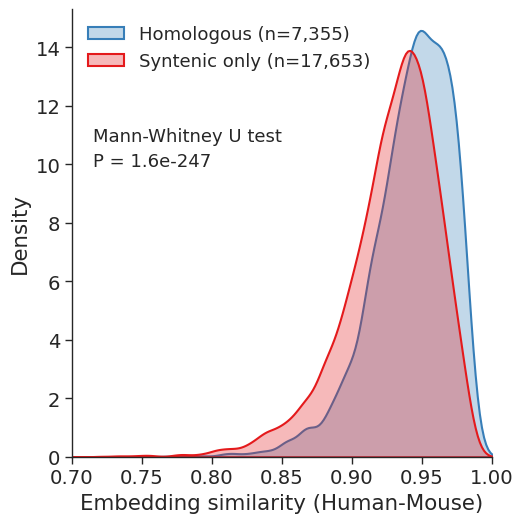

In [17]:
# 1. 数据准备
to_np = lambda x: x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
d_h, d_s = to_np(homology_cosines), to_np(syntenic_cosines)

# 2. 统计检验 (保留两位有效数字的科学计数法)
_, p_val = stats.mannwhitneyu(d_h, d_s)
p_str = f"{p_val:.1e}"

# 3. 绘图设置 (去除粗体，仅画KDE)
sns.set_theme(style="ticks", context="paper", font_scale=1.6)
plt.figure(figsize=(5.5, 5.5))

# 绘制密度填充图 (fill=True, alpha控制透明度)
sns.kdeplot(d_h, fill=True, color="#377eb8", alpha=0.3, linewidth=1.5,
            label=f"Homologous (n={len(d_h):,})", clip=(0.7, 1.0))
sns.kdeplot(d_s, fill=True, color="#e41a1c", alpha=0.3, linewidth=1.5,
            label=f"Syntenic only (n={len(d_s):,})", clip=(0.7, 1.0))

# 4. 标注与修饰
ax = plt.gca()
ax.text(0.05, 0.65, f"Mann-Whitney U test\nP = {p_str}",
        transform=ax.transAxes, fontsize=13, linespacing=1.5)

plt.xlabel("Embedding similarity (Human-Mouse)")
plt.ylabel("Density")
plt.xlim(0.7, 1.0)
plt.legend(loc='upper left', frameon=False, fontsize=13)
sns.despine()

plt.tight_layout()
plt.savefig('Embedding_similarity_Human_Mouse.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Embedding_similarity_Human_Mouse.png', bbox_inches='tight', dpi=300)
plt.show()